# Electrically Stimulated Morphine Tapering Device Simulation

This notebook simulates the control logic for an electrically stimulated morphine tapering device. The model uses a weekly tapering schedule, where the daily morphine dose decreases by 20% each week. The device releases morphine every 8 hours by applying a small electrical stimulus to an electrically responsive hydrogel.

In [7]:
import time
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt

In [22]:
starting_daily_dose = 24      # mg per day
reduction_rate = 0.20         # 20% weekly decrease
weeks = 14                    # total tapering period
doses_per_day = 3             # morning, afternoon, evening

schedule = []

for week in range(1, weeks + 1):
    daily_dose = starting_daily_dose * ((1 - reduction_rate) ** (week - 1))
    single_dose = daily_dose / doses_per_day
    
    schedule.append({
        "Week": week,
        "Daily Dose (mg)": round(daily_dose, 2),
        "Dose Per Release (mg)": round(single_dose, 2),
        "Morning Dose (mg)": round(single_dose, 2),
        "Afternoon Dose (mg)": round(single_dose, 2),
        "Evening Dose (mg)": round(single_dose, 2)
    })

taper_df = pd.DataFrame(schedule)
taper_df

,Week,Daily Dose (mg),Dose Per Release (mg),Morning Dose (mg),Afternoon Dose (mg),Evening Dose (mg)
0,1,24.00,8.00,8.00,8.00,8.00
1,2,19.20,6.40,6.40,6.40,6.40
2,3,15.36,5.12,5.12,5.12,5.12
3,4,12.29,4.10,4.10,4.10,4.10
4,5,9.83,3.28,3.28,3.28,3.28
5,6,7.86,2.62,2.62,2.62,2.62
6,7,6.29,2.10,2.10,2.10,2.10
7,8,5.03,1.68,1.68,1.68,1.68
8,9,4.03,1.34,1.34,1.34,1.34
9,10,3.22,1.07,1.07,1.07,1.07


In [23]:
#Simulate electrical stimulation settings
base_current = 0.5      # mA
base_duration = 30      # minutes

stimulation_data = []

for week in range(1, weeks + 1):
    current = base_current * ((1 - reduction_rate) ** (week - 1))
    duration = base_duration * ((1 - reduction_rate) ** (week - 1))
    
    stimulation_data.append({
        "Week": week,
        "Applied Current (mA)": round(current, 3),
        "Stimulation Duration (min)": round(duration, 2)
    })

stimulation_df = pd.DataFrame(stimulation_data)
stimulation_df

,Week,Applied Current (mA),Stimulation Duration (min)
0,1,0.500,30.00
1,2,0.400,24.00
2,3,0.320,19.20
3,4,0.256,15.36
4,5,0.205,12.29
5,6,0.164,9.83
6,7,0.131,7.86
7,8,0.105,6.29
8,9,0.084,5.03
9,10,0.067,4.03


In [24]:
#Combine tables 
device_df = pd.merge(taper_df, stimulation_df, on="Week")
device_df

,Week,Daily Dose (mg),Dose Per Release (mg),Morning Dose (mg),Afternoon Dose (mg),Evening Dose (mg),Applied Current (mA),Stimulation Duration (min)
0,1,24.00,8.00,8.00,8.00,8.00,0.500,30.00
1,2,19.20,6.40,6.40,6.40,6.40,0.400,24.00
2,3,15.36,5.12,5.12,5.12,5.12,0.320,19.20
3,4,12.29,4.10,4.10,4.10,4.10,0.256,15.36
4,5,9.83,3.28,3.28,3.28,3.28,0.205,12.29
5,6,7.86,2.62,2.62,2.62,2.62,0.164,9.83
6,7,6.29,2.10,2.10,2.10,2.10,0.131,7.86
7,8,5.03,1.68,1.68,1.68,1.68,0.105,6.29
8,9,4.03,1.34,1.34,1.34,1.34,0.084,5.03
9,10,3.22,1.07,1.07,1.07,1.07,0.067,4.03


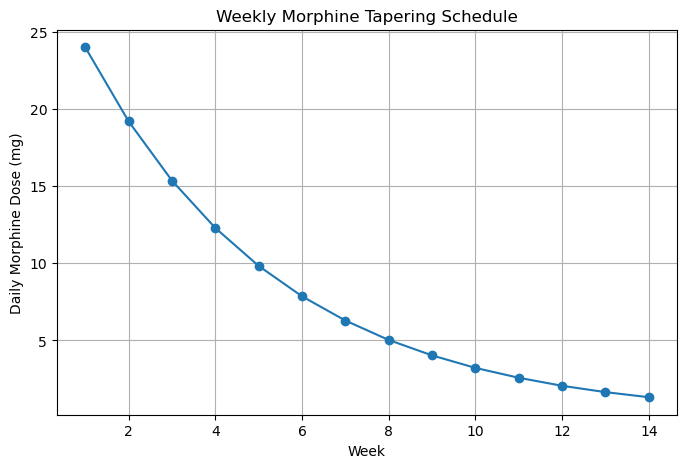

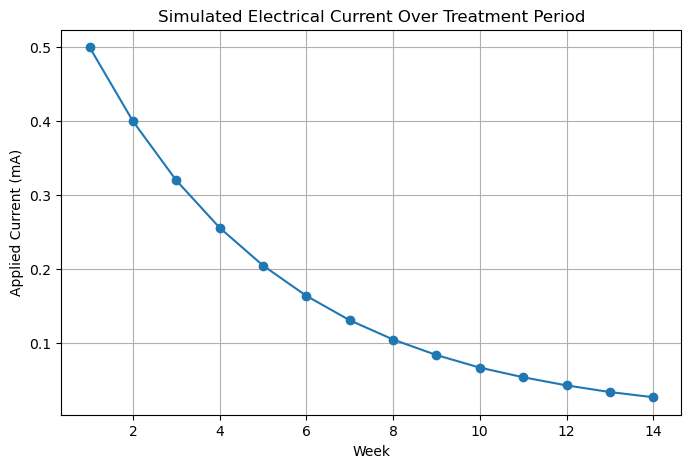

In [25]:
#Graph daily morphine dose and applied current over time
plt.figure(figsize=(8, 5))
plt.plot(device_df["Week"], device_df["Daily Dose (mg)"], marker="o")
plt.title("Weekly Morphine Tapering Schedule")
plt.xlabel("Week")
plt.ylabel("Daily Morphine Dose (mg)")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(device_df["Week"], device_df["Applied Current (mA)"], marker="o")
plt.title("Simulated Electrical Current Over Treatment Period")
plt.xlabel("Week")
plt.ylabel("Applied Current (mA)")
plt.grid(True)
plt.show()

In [26]:
#Simulate release events
release_log = []

for week in range(1, weeks + 1):
    daily_dose = device_df.loc[device_df["Week"] == week, "Daily Dose (mg)"].values[0]
    single_dose = device_df.loc[device_df["Week"] == week, "Dose Per Release (mg)"].values[0]
    current = device_df.loc[device_df["Week"] == week, "Applied Current (mA)"].values[0]
    duration = device_df.loc[device_df["Week"] == week, "Stimulation Duration (min)"].values[0]
    
    for day in range(1, 8):
        for time_period in ["Morning", "Afternoon", "Evening"]:
            release_log.append({
                "Week": week,
                "Day": day,
                "Time": time_period,
                "Dose Released (mg)": single_dose,
                "Applied Current (mA)": current,
                "Stimulation Duration (min)": duration,
                "Device Status": "Electrical stimulus applied"
            })

release_df = pd.DataFrame(release_log)
release_df.head(21)

,Week,Day,Time,Dose Released (mg),Applied Current (mA),Stimulation Duration (min),Device Status
0,1,1,Morning,8.0,0.5,30.0,Electrical stimulus applied
1,1,1,Afternoon,8.0,0.5,30.0,Electrical stimulus applied
2,1,1,Evening,8.0,0.5,30.0,Electrical stimulus applied
3,1,2,Morning,8.0,0.5,30.0,Electrical stimulus applied
4,1,2,Afternoon,8.0,0.5,30.0,Electrical stimulus applied
5,1,2,Evening,8.0,0.5,30.0,Electrical stimulus applied
6,1,3,Morning,8.0,0.5,30.0,Electrical stimulus applied
7,1,3,Afternoon,8.0,0.5,30.0,Electrical stimulus applied
8,1,3,Evening,8.0,0.5,30.0,Electrical stimulus applied
9,1,4,Morning,8.0,0.5,30.0,Electrical stimulus applied


## Analysis

The simulation shows how a morphine tapering device could gradually reduce drug release over time. The starting dose is 24 mg per day, divided into three 8 mg releases every 8 hours. Each week, the total daily dose is reduced by 20%, which lowers the amount released during each stimulation cycle.

The electrical current and stimulation duration are also reduced over time in this simulation. This represents the idea that less electrical stimulation may be needed as the required morphine release decreases. In a real medical device, these current and duration values would need to be determined through laboratory testing, direct hydrogel response measurements, and clinical validation.